In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
df=pd.read_csv('AirPassengers.csv')

In [4]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
## Augmented Dickey-Fuller (ADF) Test

## The ADF test is a Hypothesis test used to assess whether a time series is stationary or not.
## The Null Hypothesis (H0) of the ADF test is that the time series is non-stationary, 
## meaning it has a unit root. If the test statistic is less than the critical values, 
## we reject the null hypothesis and conclude that the series is stationary.

In [8]:
passengers=df['#Passengers']      ## Extract the data 
adf_result=adfuller(passengers)   ## adf test

In [9]:
test_statistic, p_value, _, _, _, _ = adf_result
print(f'Test Statistic: {test_statistic}')
print(f'P-value: {p_value}')

Test Statistic: 0.8153688792060482
P-value: 0.991880243437641


In [10]:
# (
#  test_statistic,        # ADF test statistic (float)
#  p_value,               # p-value of the test (float)
#  used_lag,              # Number of lags used in the test (int)
#  n_obs,                 # Number of observations used for the ADF regression (int)
#  critical_values,       # Critical values for 1%, 5%, 10% confidence levels (dict)
#  icbest                 # Information criterion (AIC or BIC) if autolag is used (float)
# )  These are the parameters of adfuller, in the above code, underscore in their place means, we dont care about the rest

In [11]:
## Null Hypothesis is rejected, the time-series dataset is non-stationary

In [12]:
## Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test
## The KPSS test is another hypothesis test used to check for stationarity in a time series. 
## The null hypothesis (H0) of the KPSS test is that the time series is stationary around a deterministic trend. 
## If the test statistic is less than the critical values, we fail to reject the null hypothesis, indicating stationarity.

## The KPSS test generates a test statistic and a p-value. 
## In this test, if the p-value is greater than the chosen significance level (usually set at 0.05), 
## you fail to reject the null hypothesis, indicating stationarity.

In [15]:
kpss_result=kpss(passengers,regression='c')
print("\\nKPSS Test:")
print(f'Test Statistic: {kpss_result[0]}')
print(f'P-value: {kpss_result[1]}')
if kpss_result[1] > 0.05:
	print('Fail to reject the null hypothesis: The time series is stationary.')
else:
	print('Reject the null hypothesis: The time series is non-stationary.')

\nKPSS Test:
Test Statistic: 1.6513122354165206
P-value: 0.01
Reject the null hypothesis: The time series is non-stationary.


C:\Users\91637\AppData\Local\Temp\ipykernel_12156\1798919905.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result=kpss(passengers,regression='c')


In [16]:
## regression='c' is one of the options that defines what the null hypothesis assumes.
## 'c'----> Time series is stationary around a constant (level)
## 'ct'----> Time series is stationary around a deterministic trend

In [17]:
## Line Plot 



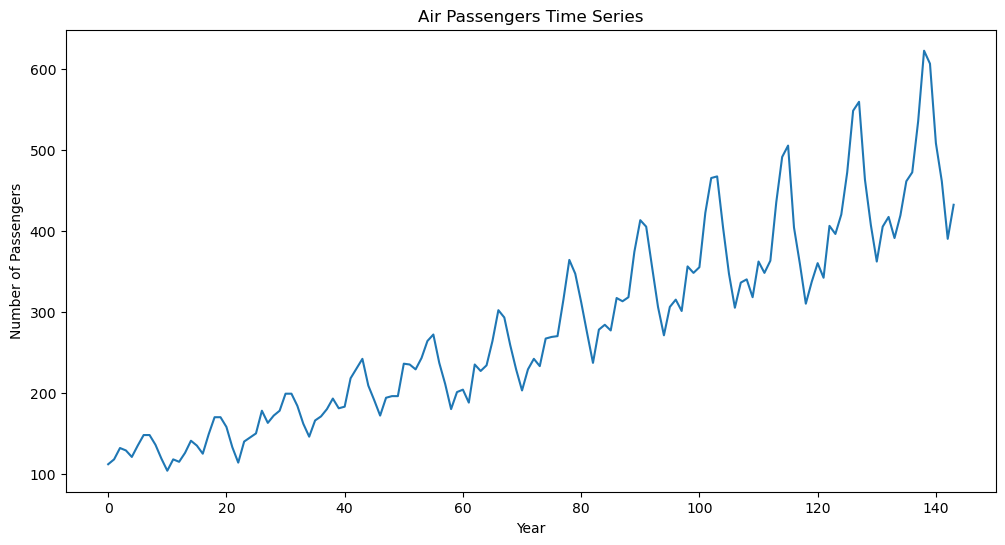

In [19]:
# create a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=df.index, y=passengers)

plt.title('Air Passengers Time Series')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')

plt.show()

In [22]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [23]:
## Seasonal Decomposition Plot

C:\Users\91637\AppData\Local\Temp\ipykernel_12156\2067754981.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  passengers.index = pd.date_range(start='1949-01', periods=len(passengers), freq='M')


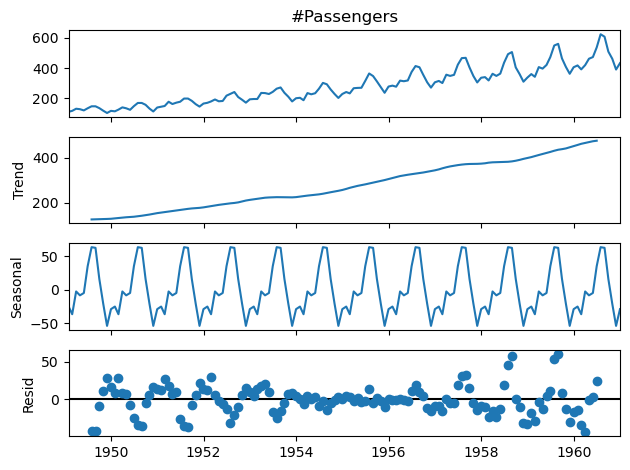

In [26]:
# make the datetime column as index
passengers.index = pd.date_range(start='1949-01', periods=len(passengers), freq='M')

# perform seasonal decomposition
decomposition = seasonal_decompose(passengers, model='additive')

# plot the decomposed components
decomposition.plot()
plt.show()

In [27]:
## model='additive' ----->  Y[t] = Trend[t] + Seasonality[t] + Residual[t]
## 	model='multiplicative' ------>  Y[t] = Trend[t] × Seasonality[t] × Residual[t]


In [28]:
## ACF Plot

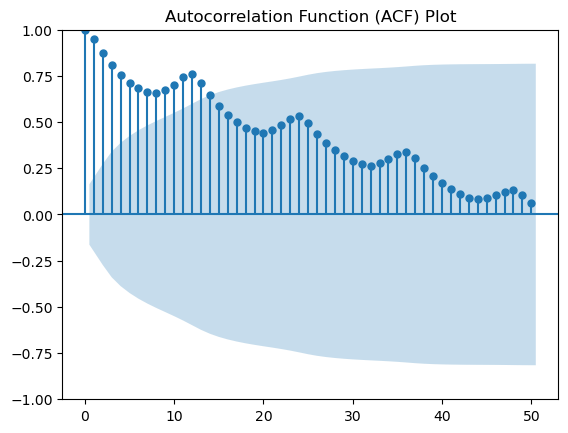

In [29]:
# create an ACF plot
plot_acf(passengers, lags=50)
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()

In [31]:
## PACF Plot

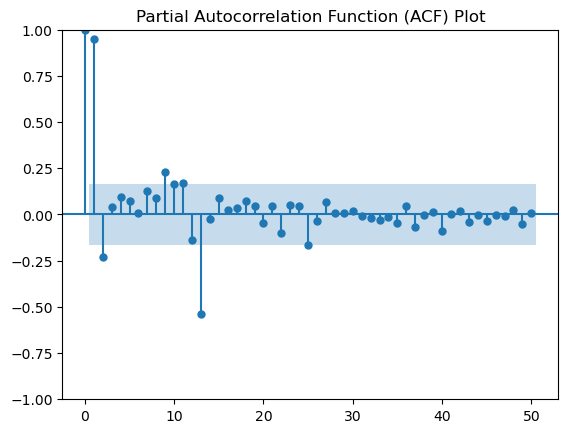

In [32]:
# create an PACF plot
plot_pacf(passengers, lags=50)
plt.title('Partial Autocorrelation Function (ACF) Plot')
plt.show()